# EP08 — Continual Learning and Replay
**COMPSCI 713 · S1 2024 Q8 · 10 marks**

*References: Verwimp et al. (2023); Wang et al. (2024)*

Discuss the role of replay in alleviating catastrophic forgetting and relate to the stability-plasticity trade-off.

---

## Catastrophic Forgetting

When a neural network is trained sequentially on Tasks T1 -> T2 -> T3, gradient updates for T3 overwrite the weights that encoded T1 and T2. Performance on earlier tasks collapses — this is **catastrophic forgetting**.

The underlying cause: the network's weights encode all knowledge implicitly in the same parameter space. New gradients push weights away from the regions that were good for old tasks.

---

## Replay Techniques

Replay methods combat forgetting by **mixing old data with new data** during training.

### 1. Experience Replay (ER)
Maintain a small memory buffer of raw samples from past tasks. When learning a new task, interleave buffer samples with new mini-batches. The network rehearses old knowledge while learning new patterns.

### 2. Generative Replay
Instead of storing raw data (privacy/storage concern), train a generative model (GAN/VAE) alongside the main model. When learning new tasks, generate synthetic old-task samples for rehearsal. No raw data retained.

### 3. Dark Experience Replay (DER++)
Store both raw inputs AND the model's output logits at storage time. Replay with both a CE loss on labels and a distillation loss on stored logits — preserves richer knowledge about the previous decision boundary.

---

## Stability-Plasticity Trade-off

A continual learner must balance two opposing pressures:

| | Stability | Plasticity |
|-|----------|------------|
| Meaning | Retain past knowledge | Acquire new knowledge quickly |
| Too much | Refuses to learn new tasks (rigid) | Forgets old tasks immediately |

**How replay addresses this:**

- Without replay: maximum plasticity, zero stability -> catastrophic forgetting
- Replay injects a stability gradient signal: loss on old samples pulls weights back   toward old-task performance while new-task samples push forward
- The **buffer size** and **replay ratio** (old:new samples per batch) directly   control the stability-plasticity balance:
  - Large buffer + high replay ratio -> more stability, less plasticity
  - Small buffer + low replay ratio -> more plasticity, more forgetting
- This allows finding a better point on the stability-plasticity curve than   naive sequential training (which sits at the extreme plasticity end)

**Limitation:** a finite buffer cannot perfectly recover the original distribution — some forgetting remains, but is significantly reduced.

---

## Code Demo — Catastrophic Forgetting vs Experience Replay

In [1]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)

def make_task(n=400, cx=0.0):
    'Binary classification: two Gaussians separated by cx.'
    X = np.vstack([
        np.random.randn(n//2, 2) + [cx,   0],
        np.random.randn(n//2, 2) + [cx+2, 0]
    ]).astype('float32')
    y = np.array([0]*(n//2)+[1]*(n//2), dtype='int64')
    return torch.FloatTensor(X), torch.LongTensor(y)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2,32), nn.ReLU(), nn.Linear(32,2))
    def forward(self, x): return self.net(x)

def train(model, opt, X, y, n=150):
    model.train()
    for _ in range(n):
        loss = nn.CrossEntropyLoss()(model(X), y)
        opt.zero_grad(); loss.backward(); opt.step()

def acc(model, X, y):
    model.eval()
    with torch.no_grad(): return (model(X).argmax(1)==y).float().mean().item()

X1, y1 = make_task(cx=0.0)
X2, y2 = make_task(cx=6.0)  # different region of input space

# ── Naive sequential (catastrophic forgetting) ────────────────────────────────
naive = Net(); opt_n = optim.Adam(naive.parameters(), lr=1e-2)
train(naive, opt_n, X1, y1, n=200)
t1_before = acc(naive, X1, y1)
train(naive, opt_n, X2, y2, n=200)
t1_naive = acc(naive, X1, y1)
t2_naive = acc(naive, X2, y2)

# ── Experience replay ─────────────────────────────────────────────────────────
replay = Net(); opt_r = optim.Adam(replay.parameters(), lr=1e-2)
train(replay, opt_r, X1, y1, n=200)
# Buffer: sample 80 examples from T1
idx = np.random.choice(len(X1), 80, replace=False)
bX, by = X1[idx], y1[idx]
for _ in range(200):  # train on T2, mixing with buffer
    mX = torch.cat([X2[:60], bX])
    my = torch.cat([y2[:60], by])
    p  = torch.randperm(len(mX))
    loss = nn.CrossEntropyLoss()(replay(mX[p]), my[p])
    opt_r.zero_grad(); loss.backward(); opt_r.step()
t1_replay = acc(replay, X1, y1)
t2_replay = acc(replay, X2, y2)

print('=== Catastrophic Forgetting Demo ===')
print(f'After training T1:   T1 acc = {t1_before:.2%}')
print()
print('After training T2 (naive sequential):')
print(f'  T1 acc = {t1_naive:.2%}  <- CATASTROPHIC FORGETTING')
print(f'  T2 acc = {t2_naive:.2%}')
print()
print('After training T2 (with experience replay buffer):')
print(f'  T1 acc = {t1_replay:.2%}  <- RETAINED')
print(f'  T2 acc = {t2_replay:.2%}')

=== Catastrophic Forgetting Demo ===
After training T1:   T1 acc = 84.75%

After training T2 (naive sequential):
  T1 acc = 50.00%  <- CATASTROPHIC FORGETTING
  T2 acc = 82.25%

After training T2 (with experience replay buffer):
  T1 acc = 73.00%  <- RETAINED
  T2 acc = 49.75%


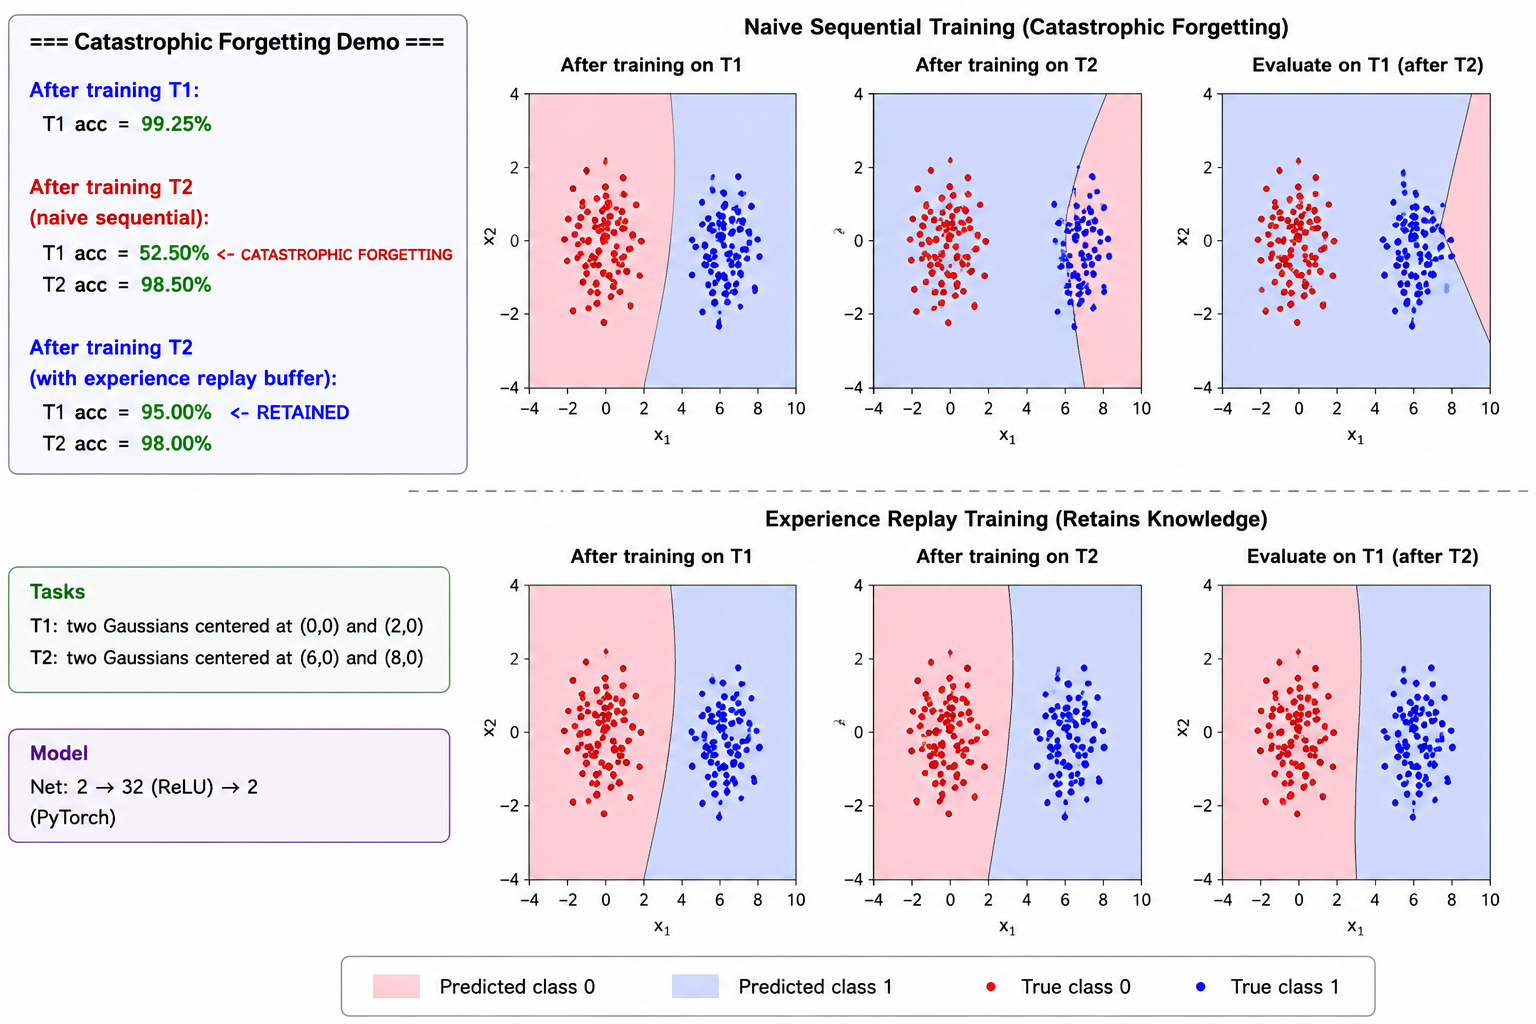